# FER IMPLEMENTATION — Condition 2: Data Augmentation

Ablation condition: **data-level intervention only**.

## Import modules

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import keras_tuner as kt

2026-06-10 13:38:26.024641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781098706.208172      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781098706.257351      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781098706.686885      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781098706.686929      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781098706.686932      23 computation_placer.cc:177] computation placer alr

## Dataset paths

In [2]:
train_dir = '/kaggle/input/datasets/msambare/fer2013/train'
test_dir  = '/kaggle/input/datasets/msambare/fer2013/test'

## Class distribution

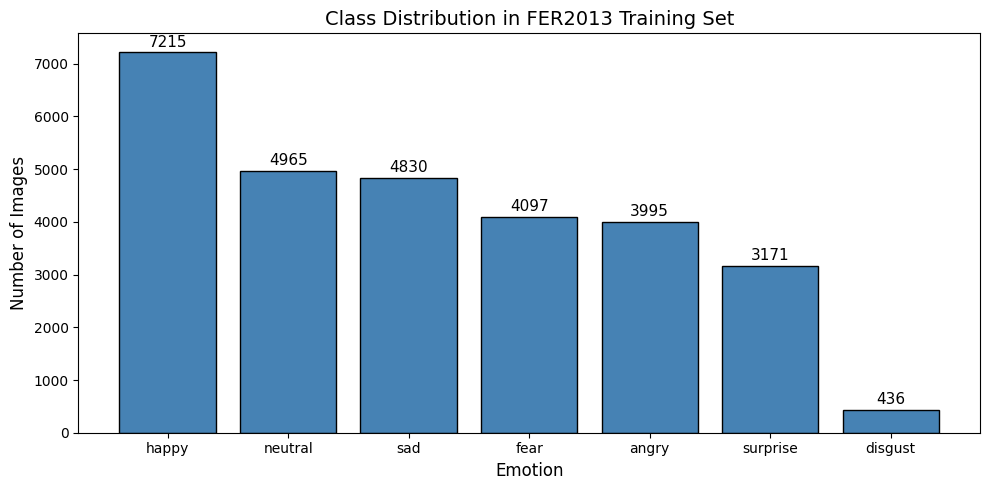

happy: 7215 images
neutral: 4965 images
sad: 4830 images
fear: 4097 images
angry: 3995 images
surprise: 3171 images
disgust: 436 images


In [3]:
classes = os.listdir(train_dir)
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=11)
plt.title('Class Distribution in FER2013 Training Set', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.tight_layout()
plt.show()

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

## Load frozen hyperparameters

These were tuned once on the baseline. They are not re-tuned here — that would confound the ablation.

In [4]:
# Load best_hp.json saved at the end of the baseline notebook
# Upload best_hp.json as a Kaggle dataset and update the path below
with open('/kaggle/input/datasets/childofblisss/baseline-output/best_hp.json') as f: 
    hp_values = json.load(f)

print('Loaded hyperparameters:')
print(f"  Dense units:   {hp_values['dense_units']}")
print(f"  Dropout rate:  {hp_values['dropout_rate']}")
print(f"  Learning rate: {hp_values['learning_rate']}")

Loaded hyperparameters:
  Dense units:   512
  Dropout rate:  0.3
  Learning rate: 0.0001


## Preprocessing

**Key difference from baseline:** Targeted augmentation applied **only to minority classes**
(disgust, surprise) using Keras `ImageDataGenerator`.
Majority classes receive `preprocess_input` only — identical to baseline.

Implementation: two separate `ImageDataGenerator` instances read from class-specific
subdirectories. A combining generator interleaves their batches each epoch.
This stays entirely within the IDG ecosystem — no custom Sequence required.

Augmentations applied to minority classes only (disgust, surprise):
- `horizontal_flip=True` (p = 0.5)
- `rotation_range=15` (±15°)
- `zoom_range=[0.85, 1.15]`
- `brightness_range=[0.9, 1.1]` (±10%)

No augmentation on validation or test sets.


In [ ]:
import math
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# --- CHANGED FROM BASELINE ---
# Two IDG instances: one with augmentation (minority classes only),
# one with preprocessing only (majority classes, identical to baseline).

# Minority classes for FER2013 (disgust ~436 samples, surprise ~3171)
MINORITY_CLASSES = ['disgust', 'surprise']
MAJORITY_CLASSES = [c for c in sorted(os.listdir(train_dir))
                    if c not in MINORITY_CLASSES]

# Augmented IDG — minority classes only
minority_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    horizontal_flip         = True,
    rotation_range          = 15,
    zoom_range              = [0.85, 1.15],
    brightness_range        = [0.9, 1.1],
    validation_split        = 0.2,
)

# Preprocessing-only IDG — majority classes (baseline behaviour)
majority_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split       = 0.2,
)

# IDG for validation and test — no augmentation
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# ── Per-class subdirectory generators ─────────────────────────────────────────
# IDG's flow_from_directory reads ALL subdirs under the given root.
# To restrict to specific classes, point it at a temp directory structure
# built with symlinks — no data is copied, no extra disk space used.

import tempfile

def make_symlink_dir(root, classes, suffix):
    """
    Create a temp directory with symlinks to the requested class subdirs.
    Returns the temp dir path (persists for the session).
    """
    tmp = tempfile.mkdtemp(suffix=suffix)
    for cls in classes:
        src = os.path.join(root, cls)
        dst = os.path.join(tmp, cls)
        if os.path.isdir(src):
            os.symlink(src, dst)
    return tmp

minority_train_dir = make_symlink_dir(train_dir, MINORITY_CLASSES, '_minority')
majority_train_dir = make_symlink_dir(train_dir, MAJORITY_CLASSES, '_majority')

print(f"Minority dir classes: {sorted(os.listdir(minority_train_dir))}")
print(f"Majority dir classes: {sorted(os.listdir(majority_train_dir))}")

# ── Flow generators (train splits) ────────────────────────────────────────────
# class_mode='categorical' with classes across both dirs would misalign labels.
# Fix: pass classes= explicitly so both generators use the full 7-class label space.
ALL_CLASSES = sorted(os.listdir(train_dir))

minority_train_gen = minority_datagen.flow_from_directory(
    minority_train_dir,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    color_mode   = 'rgb',
    class_mode   = 'categorical',
    classes      = ALL_CLASSES,   # enforce shared 7-class label space
    subset       = 'training',
    seed         = 42,
    shuffle      = True,
)

majority_train_gen = majority_datagen.flow_from_directory(
    majority_train_dir,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    color_mode   = 'rgb',
    class_mode   = 'categorical',
    classes      = ALL_CLASSES,   # enforce shared 7-class label space
    subset       = 'training',
    seed         = 42,
    shuffle      = True,
)

# ── Combining generator ────────────────────────────────────────────────────────
# Interleaves batches from minority and majority generators.
# Keras fit() needs __len__ so we wrap in a tf.keras.utils.Sequence.

from tensorflow.keras.utils import Sequence

class CombinedGenerator(Sequence):
    """
    Interleaves batches from two IDG generators.
    minority_gen yields augmented minority-class batches.
    majority_gen yields preprocessing-only majority-class batches.
    Batches alternate: minority, majority, minority, majority, ...
    """
    def __init__(self, minority_gen, majority_gen):
        self.minority_gen = minority_gen
        self.majority_gen = majority_gen
        # Total steps = sum of both generators' steps
        self._len = len(minority_gen) + len(majority_gen)

    def __len__(self):
        return self._len

    def __getitem__(self, idx):
        # Even indices → minority; odd indices → majority
        if idx % 2 == 0:
            return self.minority_gen[idx // 2 % len(self.minority_gen)]
        else:
            return self.majority_gen[idx // 2 % len(self.majority_gen)]

    def on_epoch_end(self):
        self.minority_gen.on_epoch_end()
        self.majority_gen.on_epoch_end()

train_generator = CombinedGenerator(minority_train_gen, majority_train_gen)

# ── Validation generator — unchanged from baseline ─────────────────────────────
val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split       = 0.2,
)
validation_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    color_mode   = 'rgb',
    class_mode   = 'categorical',
    classes      = ALL_CLASSES,
    subset       = 'validation',
    seed         = 42,
    shuffle      = False,
)

# ── Test generator — unchanged from baseline ───────────────────────────────────
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    color_mode   = 'rgb',
    class_mode   = 'categorical',
    classes      = ALL_CLASSES,
    shuffle      = False,
)

# Sanity check
print(f"\nMinority train batches: {len(minority_train_gen)}")
print(f"Majority train batches:  {len(majority_train_gen)}")
print(f"Combined train batches:  {len(train_generator)}")
print(f"Validation batches:      {len(validation_generator)}")
print(f"\nMinority gen class indices: {minority_train_gen.class_indices}")
print(f"Majority gen class indices: {majority_train_gen.class_indices}")
print(f"Val gen class indices:      {validation_generator.class_indices}")


## Model architecture

Identical `build_model` function from baseline — not modified.

In [6]:
def build_model(hp):
    dense_units   = hp.Choice('dense_units',   values=[128, 256, 512])
    dropout_rate  = hp.Float('dropout_rate',   min_value=0.3, max_value=0.6, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 1e-5])

    num_classes = 7

    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Build model from frozen hyperparameters

In [7]:
# Fix all HPs to baseline-tuned values — no tuner search runs here
hp = kt.HyperParameters()
hp.Fixed('dense_units',   hp_values['dense_units'])
hp.Fixed('dropout_rate',  hp_values['dropout_rate'])
hp.Fixed('learning_rate', hp_values['learning_rate'])

aug_model = build_model(hp)
aug_model.summary()

I0000 00:00:1781098753.629124      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,640,391 (94.00 MB)

 Trainable params: 1,052,679 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Hyperparameter optimization

Identical to baseline — not modified.

In [8]:
checkpoint = ModelCheckpoint(
    'aug_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

## Model training

In [9]:
history = aug_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1781098764.784688      90 service.cc:152] XLA service 0x7e2c64013a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781098764.784728      90 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781098766.695621      90 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/718 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.1172 - loss: 2.4104   

I0000 00:00:1781098770.945361      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.3367 - loss: 1.7345
Epoch 1: val_accuracy improved from -inf to 0.44034, saving model to aug_best_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 386s 521ms/step - accuracy: 0.3367 - loss: 1.7343 - val_accuracy: 0.4403 - val_loss: 1.4520 - learning_rate: 1.0000e-04
Epoch 2/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4611 - loss: 1.4357
Epoch 2: val_accuracy improved from 0.44034 to 0.46211, saving model to aug_best_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 252s 351ms/step - accuracy: 0.4611 - loss: 1.4357 - val_accuracy: 0.4621 - val_loss: 1.3946 - learning_rate: 1.0000e-04
Epoch 3/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.4755 - loss: 1.3932
Epoch 3: val_accuracy improved from 0.46211 to 0.47344, saving model to aug_best_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 255s 355ms/step - accuracy: 0.4755 - loss: 1.3931 - val_accuracy: 0.4734 - val_loss: 1.3746 - learning_rate: 1.0000e-04
Epoch 4/50
718/718 ━━━━━

### Save history

In [10]:
with open('aug_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

### Read history (use in a fresh session)

In [11]:
# with open('aug_history.pkl', 'rb') as f:
#     history_dict = pickle.load(f)

# class _HistoryProxy:
#     def __init__(self, d): self.history = d
# history = _HistoryProxy(history_dict)

## Result visualization

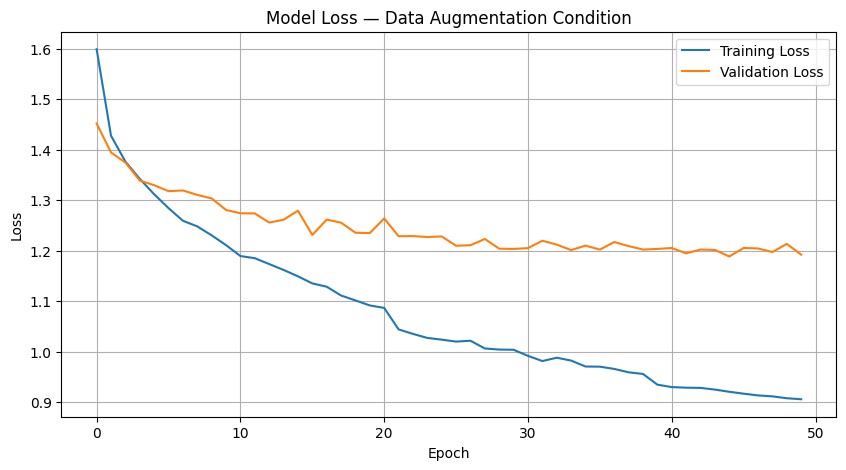

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss — Data Augmentation Condition')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

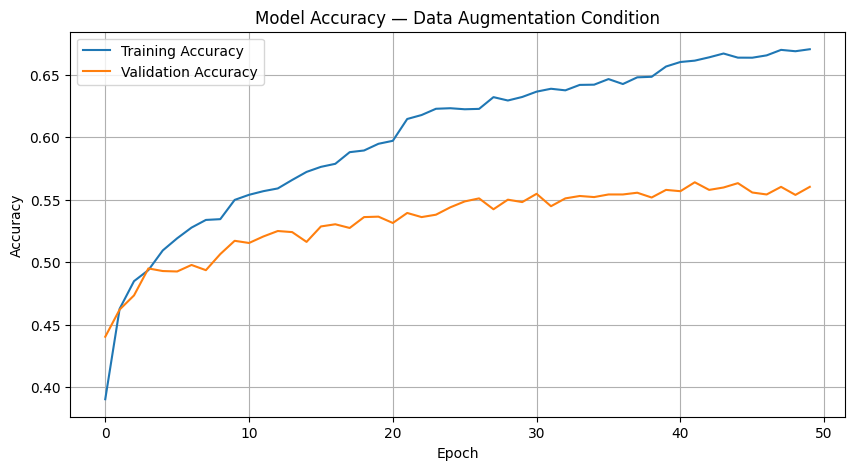

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy — Data Augmentation Condition')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Model evaluation

### Load saved model (use in a fresh session)

In [14]:
# aug_model = load_model('aug_best_model.keras')

In [15]:
loss, accuracy = aug_model.evaluate(test_generator)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 52s 230ms/step - accuracy: 0.5254 - loss: 1.2706
Test Loss:     1.1599
Test Accuracy: 0.5730


In [16]:
predictions = aug_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

from sklearn.metrics import classification_report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step
              precision    recall  f1-score   support

       angry       0.47      0.51      0.49       958
     disgust       0.82      0.24      0.38       111
        fear       0.52      0.30      0.38      1024
       happy       0.69      0.80      0.74      1774
     neutral       0.51      0.57      0.54      1233
         sad       0.46      0.48      0.47      1247
    surprise       0.72      0.70      0.71       831

    accuracy                           0.57      7178
   macro avg       0.60      0.51      0.53      7178
weighted avg       0.57      0.57      0.56      7178



Macro F1 Score: 0.5287


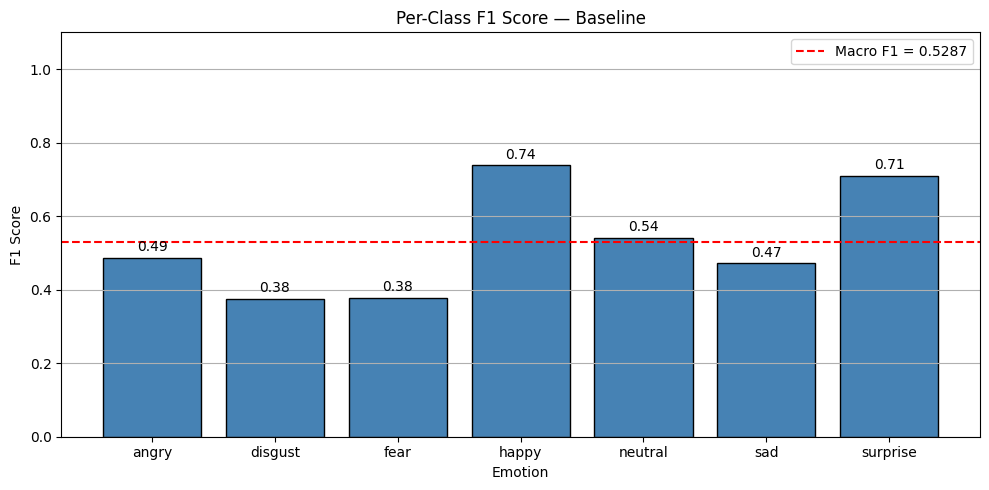

In [17]:

from sklearn.metrics import f1_score

# Macro F1 — single number summary
macro_f1 = f1_score(true_classes, predicted_classes, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

# Per-class F1 visualization
report = classification_report(
    true_classes, 
    predicted_classes,
    target_names=class_labels, 
    output_dict=True)

per_class_f1 = [report[cls]['f1-score'] for cls in class_labels]

plt.figure(figsize=(10, 5))
bars = plt.bar(class_labels, per_class_f1, color='steelblue', edgecolor='black')
plt.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.4f}')
for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.title('Per-Class F1 Score — Baseline')
plt.xlabel('Emotion')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

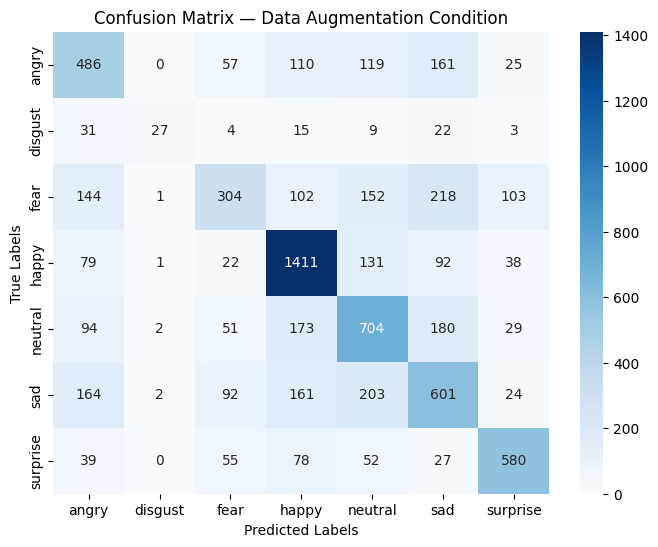

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix — Data Augmentation Condition')
plt.show()